# Capstone C — Solution: Drift Predictor & Recalibration Interval
#
**Dataset:** NOAA GML globally-averaged CO₂ monthly means — Lan, X., Thoning, K.W., Dlugokencky, E.J., *Trends in globally-averaged CO₂*, Version 2026-09, https://gml.noaa.gov/ccgg/trends/ (U.S. Government work, fair credit required)
#
ตัวอย่างเฉลยเต็มของแทร็ก C — ทุกข้อทำครบ พร้อมการตีความ ใช้เทียบกับงานผู้เรียน หรือเป็นแนวทางให้ผู้สอน

In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise FileNotFoundError("ไม่พบ datasets/ — รันโน้ตบุ๊กจากใน repo")

DATA = data_dir()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]

raw = pl.read_csv(DATA / "co2_mm_gl.csv", comment_prefix="#")
df = raw.with_columns(
    pl.when(pl.col("average") < 0).then(None).otherwise(pl.col("average")).alias("average")
).drop_nulls("average")
v = df["average"].to_numpy()
dec = df["decimal"].to_numpy()
month = df["month"].to_numpy()
N = len(v)

## ข้อ 1 — มองและถอดองค์ประกอบ

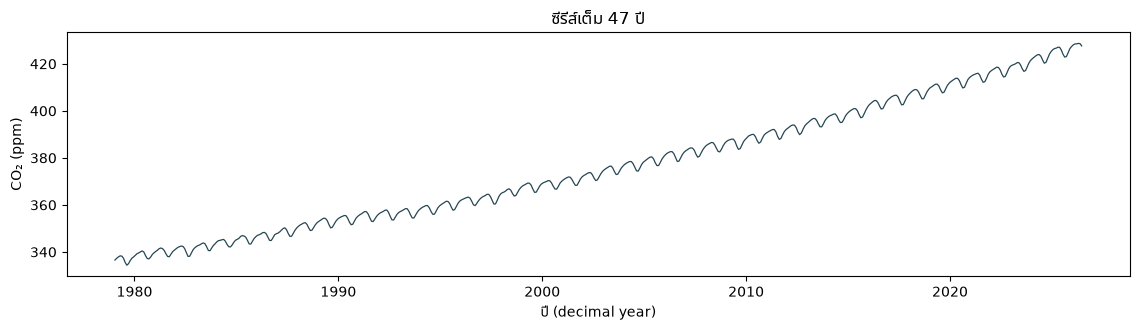

อัตรา drift เฉลี่ย: 1.91 ppm/ปี
amplitude ฤดูกาล: 4.38 ppm
residual std: 0.243 ppm


In [3]:
fig, ax = plt.subplots(figsize=(11.5, 3.4))
ax.plot(dec, v, color="#264653", lw=0.9)
ax.set_xlabel("ปี (decimal year)"); ax.set_ylabel("CO₂ (ppm)")
ax.set_title("ซีรีส์เต็ม 47 ปี")
fig.tight_layout()
plt.show()

s = df["average"]
trend = s.rolling_mean(window_size=12, center=True, min_samples=6)
det = (s - trend).to_numpy()
seas_prof = np.array([np.nanmean(det[month == m]) for m in range(1, 13)])
seasonal = seas_prof[month - 1]
resid_decomp = det - seasonal

drift_rate = (trend[-1] - trend[0]) / (N / 12)
print(f"อัตรา drift เฉลี่ย: {drift_rate:.2f} ppm/ปี")
print(f"amplitude ฤดูกาล: {seas_prof.max() - seas_prof.min():.2f} ppm")
print(f"residual std: {np.nanstd(resid_decomp):.3f} ppm")

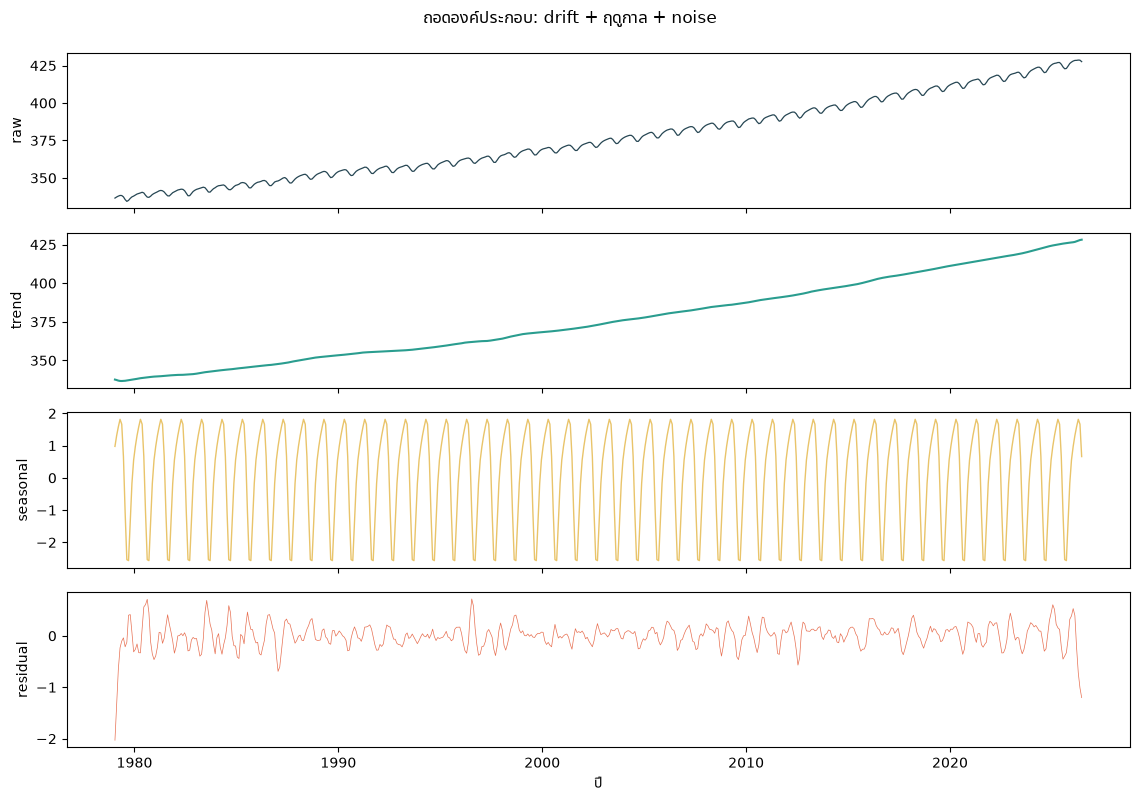

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(11.5, 8), sharex=True)
axes[0].plot(dec, v, color="#264653", lw=0.9); axes[0].set_ylabel("raw")
axes[1].plot(dec, trend.to_numpy(), color="#2a9d8f", lw=1.5); axes[1].set_ylabel("trend")
axes[2].plot(dec, seasonal, color="#e9c46a", lw=1.0); axes[2].set_ylabel("seasonal")
axes[3].plot(dec, resid_decomp, color="#e76f51", lw=0.5); axes[3].set_ylabel("residual")
axes[3].set_xlabel("ปี")
fig.suptitle("ถอดองค์ประกอบ: drift + ฤดูกาล + noise", y=0.995)
fig.tight_layout()
plt.show()

**อ่านผล:** drift ~1.9 ppm/ปี (โค้งเร่ขึ้นเล็กน้อยท้าย ๆ) · ฤดูกาล amplitude ~4.4 ppm วนรอบปีเดียว · residual std ~0.9 ppm — ข้อมูลถูกถอดได้เกือบหมดด้วยวิธีง่าย สององค์ประกอบแรกคือ "สัญญาณ" ที่โมเดลต้องจับ องค์ประกอบที่สามคือเพดานความแม่นที่โมเดลไหนก็ไปถึงไม่ได้

## ข้อ 2 — ไม้บรรทัด: naive baselines

In [5]:
mae_persist = mean_absolute_error(v[1:], v[:-1])
mae_seas = mean_absolute_error(v[12:], v[:-12])
print(f"persistence    MAE: {mae_persist:.3f} ppm")
print(f"seasonal naive MAE: {mae_seas:.3f} ppm")

persistence    MAE: 0.795 ppm
seasonal naive MAE: 1.928 ppm


ไม้บรรทัดคือ **0.795** (persistence) — seasonal naive แพ้หนักเพราะ trend พอกสะสมระหว่างปี

## ข้อ 3 — โมเดลหลัก: lags (1, 12) + TimeSeriesSplit

In [6]:
X = np.column_stack([v[12 : N - 1], v[0 : N - 13]])
yv = v[13:]
tscv = TimeSeriesSplit(n_splits=5)

lin = LinearRegression()
maes = []
for tr, te in tscv.split(X):
    lin.fit(X[tr], yv[tr])
    maes.append(mean_absolute_error(yv[te], lin.predict(X[te])))
print("linear-level MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean:", round(float(np.mean(maes)), 3), "±", round(float(np.std(maes)), 3), "ppm")

linear-level MAE ต่อ fold: [0.77, 0.776, 0.809, 0.801, 0.79]
mean: 0.789 ± 0.014 ppm


**ตอบ (ทำไมห้ามสุ่ม fold):** ซีรีส์นี้มี trend ไต่ตลอด — ถ้าสุ่ม แถวใน train จะมีค่าจากอนาคตของแถว test (และในทางกลับกัน) โมเดลที่รู้ระดับอนาคตจะ "ทำนาย" ระดับกลาง ๆ ได้เก่งเท็จ ทั้งที่หน้าที่จริงของมันคือ **extrapolate ไปทางที่ไม่เคยเห็น** — TimeSeriesSplit จำลองเงื่อนไขจริง: โมเดลเก่า ทำนาย ข้อมูลใหม่

## ข้อ 4 — level หรือ difference สำหรับ XGBoost

In [7]:
def cv_level(model) -> list[float]:
    out = []
    for tr, te in tscv.split(X):
        model.fit(X[tr], yv[tr])
        out.append(mean_absolute_error(yv[te], model.predict(X[te])))
    return out

def cv_diff(model) -> list[float]:
    dy = v[12:] - v[: N - 12]
    i0, i1 = 12, len(dy)
    Xd = np.column_stack([dy[i0 - 1 : i1 - 1], dy[i0 - 12 : i1 - 12]])
    yd = dy[i0:]
    out = []
    for tr, te in tscv.split(Xd):
        model.fit(Xd[tr], yd[tr])
        pred = v[12 + te] + model.predict(Xd[te])   # reconstruct ระดับ
        out.append(mean_absolute_error(v[12 + te] + yd[te], pred))
    return out

xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
lin_d = LinearRegression()

results = {
    "linear / level": cv_level(LinearRegression()),
    "linear / diff": cv_diff(lin_d),
    "xgboost / level": cv_level(XGBRegressor(**xgb.get_params())),
    "xgboost / diff": cv_diff(XGBRegressor(**xgb.get_params())),
}
tbl = pl.DataFrame({
    "model": list(results),
    "mean_MAE": [round(float(np.mean(a)), 3) for a in results.values()],
    "worst_fold": [round(float(np.max(a)), 3) for a in results.values()],
}).sort("mean_MAE")
tbl

model,mean_MAE,worst_fold
str,f64,f64
"""linear / diff""",0.135,0.156
"""xgboost / diff""",0.191,0.233
"""linear / level""",0.789,0.809
"""xgboost / level""",7.337,9.5


**ตอบ:** ต้นไม้แพ้ยับบน **level** (MAE ~7.3) เพราะ tree ตอบได้เฉพาะค่าในช่วงที่ train เคยเห็น — fold test อยู่สูงเหนือขอบเขตนั้นตลอด (drift) มันจึง "ค้าง" ที่ค่าสูงสุดเก่า พอเปลี่ยนเป้าหมายเป็น **difference** ขอบเขตปัญหากลับมาอยู่ในช่วงที่เคยเห็น ต้นไม้กลับมาใช้ได้ (0.19) แต่ยังแพ้ linear บน diff (0.14) เพราะ Δ ของซีรีส์นี้เรียบจนไม่มีรูปทรงซับซ้อนให้ต้นไม้จับ — ผู้ชนะจริงคือ **linear บน differences** ตามด้วย linear บน level (0.79) ที่ยังเบียด persistence ได้
#
เลือก **linear / diff** เป็นโมเดลหลักสำหรับพยากรณ์

## ข้อ 5 — พยากรณ์ 24 เดือน + recalibration interval (tolerance +6 ppm)

In [8]:
# fit โมเดลผู้ชนะ (linear บน differences) บนข้อมูลเต็ม
dy = v[12:] - v[: N - 12]
i0, i1 = 12, len(dy)
Xd = np.column_stack([dy[i0 - 1 : i1 - 1], dy[i0 - 12 : i1 - 12]])
yd = dy[i0:]
model_d = LinearRegression().fit(Xd, yd)
sigma = float((yd - model_d.predict(Xd)).std())
print(f"residual σ (บน Δ): {sigma:.3f} ppm")

# recursive: ทำนาย Δ ทีละก้าว → ระดับถัดไป → ป้อนกลับ
TOLERANCE = 6.0   # ppm จากค่าล่าสุด
horizon = 24
hist = list(v)
fc = []
for _ in range(horizon):
    d1 = hist[-1] - hist[-13]          # Δ_{t-1}
    d12 = hist[-12] - hist[-24]        # Δ_{t-12}
    nxt = hist[-12] + float(model_d.predict(np.array([[d1, d12]]))[0])
    hist.append(nxt)
    fc.append(nxt)
fc = np.array(fc)
band = 2 * sigma * np.sqrt(np.arange(1, horizon + 1))

tol_level = v[-1] + TOLERANCE
h = np.arange(1, horizon + 1)
cross = h[fc + band >= tol_level]
interval_safe = int(cross[0]) if len(cross) else None
print(f"tolerance level: {tol_level:.2f} ppm (ค่าล่าสุด {v[-1]:.2f} + {TOLERANCE})")
print(f"ขอบบนแถบแตะ tolerance ที่ h = {interval_safe} เดือน → interval ปลอดภัย ~{max(interval_safe - 2, 1)} เดือน")

residual σ (บน Δ): 0.185 ppm
tolerance level: 433.62 ppm (ค่าล่าสุด 427.62 + 6.0)
ขอบบนแถบแตะ tolerance ที่ h = 21 เดือน → interval ปลอดภัย ~19 เดือน


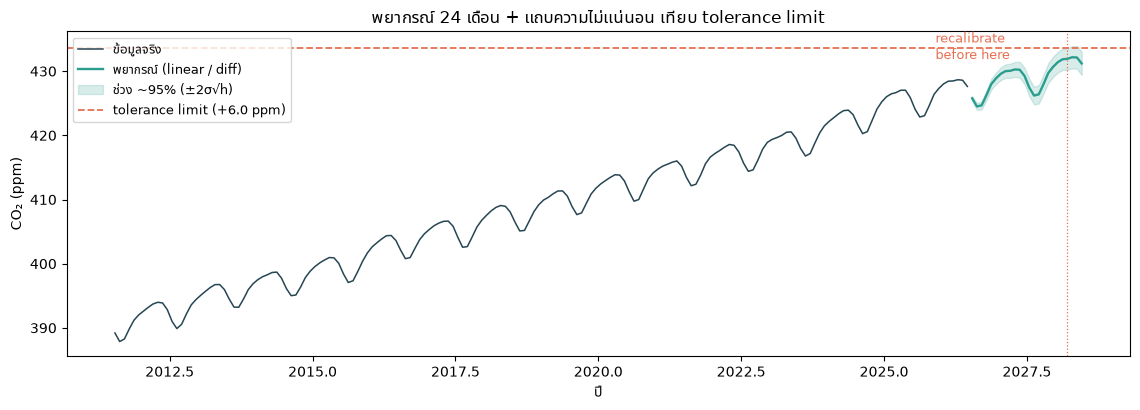

In [9]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.plot(dec[-180:], v[-180:], color="#264653", lw=1.1, label="ข้อมูลจริง")
fy = dec[-1] + np.arange(1, horizon + 1) / 12
ax.plot(fy, fc, color="#2a9d8f", lw=1.7, label="พยากรณ์ (linear / diff)")
ax.fill_between(fy, fc - band, fc + band, color="#2a9d8f", alpha=0.18, label="ช่วง ~95% (±2σ√h)")
ax.axhline(tol_level, color="#e76f51", ls="--", lw=1.3, label=f"tolerance limit (+{TOLERANCE} ppm)")
if interval_safe:
    ax.axvline(fy[interval_safe - 1], color="#e76f51", lw=0.9, ls=":")
    ax.annotate("recalibrate\nbefore here", (fy[interval_safe - 1], tol_level),
                xytext=(-95, -8), textcoords="offset points", color="#e76f51", fontsize=9)
ax.set_xlabel("ปี"); ax.set_ylabel("CO₂ (ppm)")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("พยากรณ์ 24 เดือน + แถบความไม่แน่นอน เทียบ tolerance limit")
fig.tight_layout()
plt.show()

**อ่านผล:** ขอบบนของแถบ ~95% แตะ tolerance (+6 ppm) ที่ h = **21 เดือน** — ตัด margin เหลือ **~19 เดือน** เป็น recalibration interval ที่แนะนำ เทียบกับ Module 8 ที่ใช้ linear บน level (σ = 0.93 ppm) กับ tolerance +8 ppm แล้วได้ ~11 เดือน: โมเดลบน differences แคบกว่ามาก (σ = 0.19) จึงซื้อ interval ที่ยาวขึ้นได้ **ทั้งที่ tolerance คับกว่าเดิม** — บทเรียนสองทิศ: (1) คุณภาพโมเดลแปลงเป็นรอบการสอบเทียบที่ยาวขึ้นได้โดยตรง (เงินและเวลาที่ประหยัดได้จริง), (2) tolerance ยิ่งคับ interval ยิ่งสั้น — ทิศทางเดิมยังจริง แต่แรงของแต่ละปัจจัยวัดได้จากความชันของแถบ ไม่ใช่ความรู้สึก
#
สมมุติฐานที่การตัดสินนี้พึ่งพา: (1) drift และฤดูกาลเดินต่อแบบเดิม (ไม่มีเหตุการณ์ใหม่ — กับ CO₂ โลกค่อนข้างจริง กับเครื่องมือห้องแล็บไม่จริง: เครื่องถูกซ่อม/เปลี่ยนชิ้นส่วน), (2) residual แบบ random-walk (ความไม่แน่นอนโตตาม √h), (3) tolerance นิยามจากค่าล่าสุดไม่ใช่ค่ากลางของช่วง — ทุกข้อควรแจ้งในรายงาน

## ข้อ 6 — สรุปส่งงาน (ตัวอย่าง)
#
โมเดลที่แนะนำ: **linear regression บน differences** ด้วย lags (Δt−1, Δt−12) — แม่นสุดบน CV ที่ซื่อสัตย์ (MAE 0.14 ppm) ชนะทั้ง persistence (0.80) และ XGBoost ทุกแบบบน level (7.3 — ต้นไม้ extrapolate ไม่ได้) จากแถบความไม่แน่นอน ±2σ√h กับ tolerance +6 ppm แนะนำ recalibration interval **~19 เดือน**
#
ข้อจำกัด: โมเดลสมมุติว่าพฤติกรรมการไหลเดินต่อแบบเดิม — เหตุการณ์ใหม่ (ซ่อมบำรุง, เปลี่ยน sensor, ย้ายห้อง) ทำให้พยากรณ์ใช้ไม่ได้ทันที และแถบ √h เป็น approximation แบบ random-walk ยังไม่รวมความไม่แน่นอนของพารามิเตอร์โมเดลเอง ถ้ามีเวลาอีกสัปดาห์: (1) ใช้ rolling-origin evaluation หลายจุดเริ่มแทน TimeSeriesSplit จุดเดียว เพื่อวัดความผันผวนของ interval, (2) รวม feature ภายนอก (อุณหภูมิห้องแล็บ) ถ้ามี, (3) ทำ conformal prediction แทน ±2σ เพื่อให้ช่วงมีการรับประกันเชิงสถิติจริง